<a href="https://colab.research.google.com/github/asavine/pub/blob/main/programming_assignment_2_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Programming Assignment 2

Your goal is to complete this notebook, save it in Colab, and provide a link to your work. Write code in code cells, and your answers to theoretical questions in markup cells. Recall that Colab markup has support for laTex. You can write equations inline like this: $x_1 = \alpha x_2 + x_3^2$, or on display like this:
$$
  d S_t = \sigma_t d W_t^q
$$

## Binomial Model and American Options

### Introduction

In this assignment, you will implement a variant of the classic binomial option pricing model, and use it to price and reason about American options. We will also introduce some important design patterns for pricing with numerical methods, such as the notion of state variable and reconstruction function, or the separation of concerns between models of the underlying market, numerical methods and option payoffs.

From Wikipedia (Binomial Options Pricing Model): "The binomial model was first proposed by William Sharpe in the 1978 edition of Investments (ISBN 013504605X),and formalized by Cox, Ross and Rubinstein in 1979 and by Rendleman and Bartter in that same year."

In 2025, the BOPM is widely used in the Academy to study the key notions of Arbitrage Theory in a simplified setting. Incredibly, it is also still used in the industry, in contexts where model accuracy matters less than the ability to compute hundreds of thousands of American option prices in milliseconds.

The BOPM models a discrete-time random walk $\{X_i, i \in [0,n]\}$ such that $X_0=0$ and
$$
X_{i+1}-X_i = + \alpha \text { with probability } p, \text{ or } - \alpha \text{ with probability } 1-p
$$
where $\alpha > 0$ is a given mesh, and $p \in (0,1)$ the unspecified probability of upward moves. $(X_i)$ can only move up or down over a time step, and by a fixed amount, forming a *recombining tree* of possible paths, as shown in the picture below.

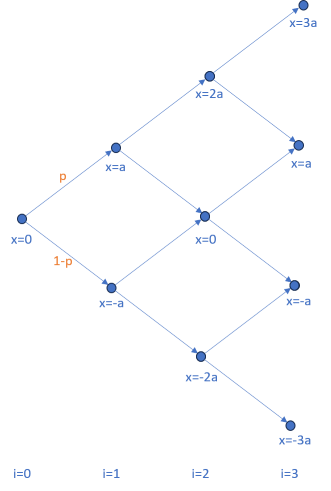

## State Variables and Reconstruction Functions

This is not how the BOPM is generally introduced. The original article, and most texbooks, work with a positive asset price $(S_i)$ and model its binomial behaviour in terms of *multiplicative moves*: $S_{i+1} = S_i \beta$ with probability $p$ or $S_i / \beta$ with probability $1-p$.

Our arithmetic variant reproduces the original model by setting $S_i = S_0 \exp(X_i)$ and $\alpha = \log(\beta)$. But it can also represent non-positive prices, for example, $S_i = S_0 + X_i$. The dynamics of the *state variable* $(X_i)$ is an arithmetic random walk in both cases, the logic is the same, and the code can be reused for different model assumptions, simply by changing the *reconstruction function* $S_i = f(X_i, i)$.

This is a simple example of a separation between state variables and asset prices. We will apply this idiom systematically in the rest of the course, particularly with interest rate models, and this is a nice opportunity to introduce it in a simple context.

The picture below illustrates a normal or lognormal instantiation. The architecture is the same, only the values of the spot price assigned to the nodes are different.

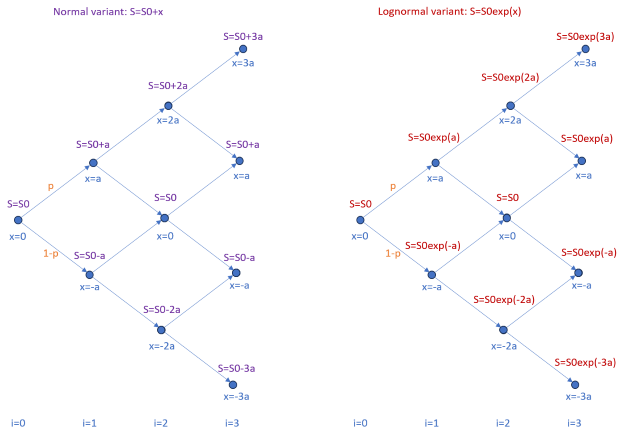

This is not just a theoretical question: your pricing code will be model-agnostic. You will build a tree for the arithmetic random walk $(X_i)$, and rely on a user-supplied reconstruction function to instantiate it with a model of the price series $(S_i)$. Hence, the same code, but with a different argument, will solve both the normal and lognormal models.

In [ ]:
def generate_reconstruction_normal(S0):

  def f(X, i):
    return S0 + X

  return f

def generate_reconstruction_lognormal(S0):

  def f(X, i):
    return S0 * np.exp(X)

  return f

Note that we used a *factory pattern* here: generate_reconstruction_normal() returns a callable who, in turn, performs the job of mapping $X$ into $S$, and encapsulates the parameter $S_0$.  

# Question 1

### Pricing equations

The model is trivially arbitrage-free as long as $\alpha>0$, $0 < p < 1$ and the reconstruction function $f$ is monotonic. You will illustrate that it is also complete by deriving the replication strategy for an arbitrary European option with payoff $g(S_n)$, and compute its prices $(C_{ij})$, on the nodes of the tree, as a by-product.

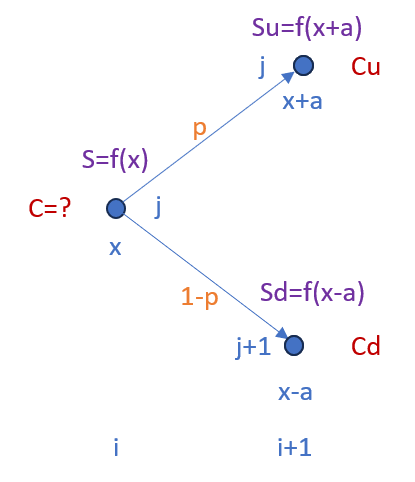

You will proceed by backward induction.

The base case is given by the usual boundary condition whereby price = payoff at maturity: $C_{nj}=g(S_{nj})=g[f(X_{nj}, n)]$.

The inductive case is illustrated in the picture above. You are standing on node $(i,j)$ so the next move lands on node $(i+1,j)$ or node $(i+1,j+1)$. The asset price $(S_{i,j})$ is known on all nodes, denoted $S$ on the current node, $S_u$ in the up scenario and $S_d$ in the down scenario. The option price is known on nodes $(i+1,j)$ by inductive hypothesis, and denoted $C_u$ and $C_d$ in the two scenarios.

1.   You want to track the option price in both scenarios, with an amount of cash $\gamma$ and a position $\delta$ on the underlying asset. Exhibit the replication equations.

2.   Show that there is a unique solution. What is $\gamma$? What is $\delta$?

3.   What is the unique value of the option price $C=C_{i,j}$ on the current node mandated by arbitrage arguments? What is the replication strategy?

4.   Explain why your formula does not depend on the probability $p$, and show that it can be written as follows:
$$
  C = q C_u + (1-q) C_d
$$
give an expression for $q$ and show that it can be interpreted as a probability, such that:
$$
  C_{ij} = E^q_{(i,j)}[C_{i+1}]
$$

5.   What is $E^q_{(i,j)}[S_{i+1}]$ ? Conclude: what really is q?

Your solution should only depend on asset prices $S$, not state variables $X$. For this reason, $q$ may depend on time and state: although the tree mesh in uniform in $X$, if may not be uniform in $S$, depending on the reconstruction function.

So $q$ should really be denoted $(q_{ij})$.


Solution:



1.   $\gamma + \delta (S_u - S) = C_u$ and $\gamma + \delta (S_d - S) = C_d$

2.   $\delta = \frac{C_u - C_d}{S_u - S_d} \approx \frac{\partial C}{\partial S}$ and $\gamma = \frac{S-S_d}{S_u-S_d} C_u + \frac{S_u - S}{S_u-S_d} C_d$ recall in order to prevent arbitrage: $S_u > S > S_d$

3.   $C = \gamma = \frac{S-S_d}{S_u-S_d} C_u + \frac{S_u - S}{S_u-S_d} C_d$ and the hedge ratio is $\delta = \frac{C_u - C_d}{S_u - S_d} \approx \frac{\partial C}{\partial S}$

4.   $(\gamma, \delta)$ provides a perfect replication in all scenarios so probability $p$ doesn't matter, and: $C = q C_u + (1-q) C_d$ where $q=\frac{S-S_d}{S_u-S_d} \in (0,1)$

5.   $E^q_{i,j}[S_{i+1}] = q S_u + (1-q) S_d = S = S_{ij}$: $q$ is the EMM



# Question 2

### Code for the induction step

Write a function that computes option prices for all nodes at time $i$, given option prices at time $i+1$, and asset prices at times $i$ and $i+1$.

Recall that there are $i+1$ nodes at step $i$, numbered from top $0$ to bottom $i$, such that $X_{ij} = (i-2j) \alpha$.

In [ ]:
# returns the array of i+1 option prices at time i
# given: the arrays of i+2 option prices and i+2 asset prices at time i+1,
#        and i+1 asset prices at time i
def backward_induction(c_i_plusone, s_i, s_i_plusone):
  # your code here
  pass

c_i_plusone = np.array([3, 6, 10, 15, 20])
s_i_plusone = np.array([80, 90, 100, 110, 120])
s_i = np.array([85, 97, 102, 113])
backward_induction(c_i_plusone, s_i, s_i_plusone)
# should return [ 4.5,  8.8, 11. , 16.5]

Solution:

In [ ]:
def backward_induction(c_i_plusone, s_i, s_i_plusone):
  q = (s_i - s_i_plusone[1:]) / (s_i_plusone[:-1] - s_i_plusone[1:])
  return q * c_i_plusone[:-1] + (1 - q) * c_i_plusone[1:]

In [ ]:
c_i_plusone = np.array([3, 6, 10, 15, 20])
s_i_plusone = np.array([80, 90, 100, 110, 120])
s_i = np.array([85, 97, 102, 113])
backward_induction(c_i_plusone, s_i, s_i_plusone)

array([ 4.5,  8.8, 11. , 16.5])

# Question 3

### Generic pricing code

At this point, the pricing function writes itself. But we are going to switch gears and explore important *design patterns* for *generic* pricing code. Well-designed, generic code is generally challenging to write, and it often makes a considerable difference in the Derivatives industry.

It is the mandate of this class to at least introduce pricing design patterns. Thankfully, the BOPM  provides a framework that is both appropriate and mercifully simplified for a meaningful introduction.

In the BOMP, generic means:

1.  **model-agnostic**: your function shoud build an arithmetic random walk for the state variable $(X_i)$, not the asset price $(S_i)$. Asset prices ($S_i$) are deduced by calling a caller-supplied function $S_i = f(X_i, i)$ such that the model logic is entirely encapsulated in this reconstruction function. As a result, the same code can instantiate a normal or longormal model, without modification, by passing a different reconstruction function.

2.  **option-agnostic**: we will not assume or hardcode European calls. Instead, the payoff at maturity is computed with a caller-supplied payoff function $g$ such that $C_{nj} = g(S_{nj}) = g[f(X_{nj})]$. Hence, a single function, written only once, can be reused to price different kinds of options.

In addition, we will not stop at European options. We will support suitable *exotic* options by letting the caller provide an *update function* as follows:

The user provides a function with signature:

In [ ]:
def update_function(
    s_i: np.ndarray[float], # array [S(i, 0), S(i, 1), ..., S(i, i)] of asset prices at time i
    i: int,                 # the time step
    c_i: np.ndarray[float], # the array [C(i, 0), C(i, 1), ..., C(i, i)]
                            # of the prices computed for time i by induction
) -> np.ndarray[float]:     # returns the prices, updated for boundary at time i
  pass

This function will be called:

1.  When the base case is computed on step $i=n$, and return the array of final payoffs.

2.  At every step of the backward induction $(i+1) \to i$, after the prices for $i$ are computed by induction so they represent the so-called *continuation value*, the price of future payoffs. The call may then modify these prices to account for additional boundaries at step $i$, or return them unchanged.

For example, the two functions below instantiate the representations of two options: the first one is a European call, the second one is a *calendar spread*. A calendar spread is a simultaneous long position on a call maturity $i_2$ and strike $K$, and a short position on a call of maturity $i_1$, with the same strike K.

In [ ]:
def generate_european_call(n_maturity, K):

  def update_func(s_i, i, c_i):
    if i == n_maturity:
      return np.maximum(s_i - K, 0)
    else:
      return c_i

  return update_func

def generate_call_spread(i1, i2, K):

  def update_func(s_i, i, c_i):
    if i == i2:
      return np.maximum(s_i - K, 0)

    elif i == i1:
      return c_i - np.maximum(s_i - K, 0)

    else:
      return c_i

  return update_func


You turn, then. Write the generic pricing function.

What you are asked to instantiate is called a *template pattern*, whereby the skeleton of a given algorithm is written once, with some steps (here: $X \to S$ mapping, and boundaries) delegated to called-supplied functions. Template patterns are particularly suitable for numerical pricing algorithms, where the same method may be written once and applied to variety of models and instruments.

Your code should return a list $L$ of couple of arrays ($S_i, C_i$), corresponding to asset and option prices on all nodes at time steps $i=0, 1, ..., n$. Hence, this is a list of $n+1$ couples of arrays of sizes $1, 2, ..., n+1$ such that $S[i][j] = L[i][0][j]$ is the asset price, and $C[i][j] = L[i][1][j]$ is the option price, at time $i$, on node $j$, counting from $j=0$ on top.

More precisely: $L[i][:][j] = (S[i][j], C[i][j])$ with $ j \leq i$ are the asset and option prices at time $i$ in the scenario $j$ where $X_{ij}= (i - 2j) \alpha$ and $S_{ij}=f(i, X_{ij})$.

For example:
*  $S[0][0]$ and $C[0][0]$ in $L[0]$ are today's asset and option price
*  $S[n][0]$ and $C[n][0]$ in $L[n][:][0]$ are the asset price and payoff at maturity in the most bullish scenario where $X_n = n \alpha$, in the case of a European call the payoff is: $C[n][0] = (S_{n,0}-K)^+=[f(n \alpha, n) - K]^+$
*  $S[n][n]$ and $C[n][n]$ in $L[n][:][n]$ are the asset price and payoff at maturity in the most bearish scenario $X_n = - n \alpha$
*  $S[i] = L[i][0]$ is an array of size $i$ of the asset prices $S[i][j]$ at time $i$, with indices $j$, ranging from $0$ (highest $X_i = i \alpha$) to $i$ (lowest $X_i = - i \alpha$), with mesh $2 \alpha$
*  $C[i] = L[i][1]$ is an array of size $i$, of the corresponding option prices



In [ ]:
from collections.abc import Sequence
from typing import Callable

def binom_pricing(
    # x-tree architecture
    n: int,
    alpha: float,
    # user-supplied reconstruction encasulates model
    reconstruction_func: Callable[[np.ndarray[float], int], np.ndarray[float]], #e.g. generate_reconstruction_normal(100)
    # user-supplied update function encapsulates instrument
    update_func: Callable[[np.ndarray[float], int, np.ndarray[float]], np.ndarray[float]], #e.g. generate_european_call(n, 100)
    # returns a sequence of size n+1 with option price arrays at times 0..n
) -> Sequence[(np.ndarray[float], np.ndarray[float])]:
  # your code here
  pass

# uncommment when you are done
# binom_pricing(5, 1, generate_reconstruction_normal(100), generate_european_call(5, 100))

# should return
#[
# ([100.], [0.9375]),
# ([101.,  99.], [1.4375, 0.4375]),
# ([102., 100.,  98.], [2.125, 0.75 , 0.125]),
# ([103., 101.,  99.,  97.], [3.  , 1.25, 0.25, 0.  ]),
# ([104., 102., 100.,  98.,  96.], [4. , 2. , 0.5, 0. , 0. ]),
# ([105., 103., 101.,  99.,  97.,  95.], [5., 3., 1., 0., 0., 0.])
# ]

Solution:

In [ ]:
def binom_pricing(
    # x-tree architecture
    n: int,
    alpha: float,
    # user-supplied reconstruction encasulates model
    reconstruction_func: Callable[[np.ndarray[float], int], np.ndarray[float]], #e.g. generate_reconstruction_normal(100)
    # user-supplied update function encapsulates instrument
    update_func: Callable[[np.ndarray[float], int, np.ndarray[float]], np.ndarray[float]], #e.g. generate_european_call(n, 100)
    # returns a sequence of size n+1 with asset and option price arrays at times 0..n
) -> Sequence[tuple[np.ndarray[float], np.ndarray[float]]]:

  x_i = np.linspace(- n * alpha, n * alpha, n + 1)[::-1] # reverse, higesth to lowest
  s_i_plusone = reconstruction_func(x_i, n)
  # payoff
  c_i = update_func(s_i_plusone, n, None)
  series = [(s_i_plusone, c_i)]

  for i in range (n - 1, -1, -1):
    # i + 1 -> i
    x_i = np.linspace(- i * alpha, i * alpha, i + 1)[::-1] # x grid
    s_i = reconstruction_func(x_i, i) # s grid
    # i + 1 -> i, c_i is in fact c_i_plusone before the call, c_i thereafter
    c_i = backward_induction(c_i, s_i, s_i_plusone)
    # boundary update
    c_i = update_func(s_i, i, c_i)
    # save in results
    series.append((s_i, c_i))
    # s_i becomes s_i_plusone for the next iteration (previous time step)
    s_i_plusone = s_i

  return list(reversed(series))

In [ ]:
binom_pricing(5, 1, generate_reconstruction_normal(100), generate_european_call(5, 100))

[(array([100.]), array([0.9375])),
 (array([101.,  99.]), array([1.4375, 0.4375])),
 (array([102., 100.,  98.]), array([2.125, 0.75 , 0.125])),
 (array([103., 101.,  99.,  97.]), array([3.  , 1.25, 0.25, 0.  ])),
 (array([104., 102., 100.,  98.,  96.]), array([4. , 2. , 0.5, 0. , 0. ])),
 (array([105., 103., 101.,  99.,  97.,  95.]),
  array([5., 3., 1., 0., 0., 0.]))]

# Question 4a

### Mapping to continuous models

You answer to the previous question computed the *exact* option prices in the discrete BOPM model. However, it is hard to get a feel for the BOPM parameters $n$ and $\alpha$ and test your function with a meaningful parameter set.

You will now use the BOPM as an *approximation* for a continuous model, such as Bachelier or Black and Scholes. In other terms, you will no longer consider its results as the exact solution under the discrete model, but as an approximation of the solution under a continuous model: you will use the BOPM as a *numerical method*.

Therefore, you want your state variable $(X_i)$ to converge to a scaled Brownian Motion $(\sigma W_{T_i})$ when $n \to ∞$. Fix a maturity $T$ and a number of steps $n$, and define $\Delta_t = T / n$, and $T_i = i \Delta t = i T / n$ the time on step $i \in [0, n]$.

Since we have seen that $p$ doesn't matter, set it to $1/2$ in order to (considerably) facilitate calculation.

Consider two steps $i_2 > i_1 >= 0$:

1. What is the distribution of $X_{i_2}$ given $X_{i_1}$?

2. What is the limit distribution when $n \to ∞$?

3. What is the *target* distribution of $\sigma W_{T_{i2}}$ given $\sigma W_{T_{i1}}$?

4. Conjecture the required scaling of $\alpha$, and prove that, with your scaling, $(X_i)$ indeed converges to $(\sigma W_t)$.



Solution:

1. The distribution of $X_{i_2}$ given $X_{i_1}$ is observed on the (sub-) trees rooted on the nodes $X_{i_1, j}$. Hence, the distribution is:
$$
  X_{i_2} - X_{i_1} \sim 2 \cdot binom(i_2 - i_1; p=1/2) - (i_2 - i_1)] \alpha
$$

2. The limit distribution is normal, with expection $0$ and variance $(i_2 - i_1) \alpha^2$

3. $\sigma (W_{T_{i2}} - W_{T_{i1}}) $ is normal, with expectation $0$ and variance $ (T_{i2} - T_{i1}) \sigma^2 = (i_2 - i_1) \sigma^2 \Delta_t$

4. Hence, it must be that: $\alpha = \sigma \Delta_t$. Conversely, if this is the case, then $(X_i)$ converges to a continuous-time process, with independent, Gaussian increments with expectation $0$ and variance $\sigma^2 \Delta_t$, hence, a correctly scaled Brownian Motion.

# Question 4b

### Mapping to continuous models

Write a wrapper function that accepts the usual maturity and volatility parameters, translates them into appropriate BOPM parameters and calls your previous function. It should return a dictionary $\{T_i: (S_i, C_i)\}$.

This kind of wrapping that transates inputs, makes a call to the main computation, and translates outputs, is called an *adapter pattern*.

Write closed-form pricing functions for European calls in Bachelier and Black and Scholes, and check convergence.

In [ ]:
from typing import Dict

def binom_wrapper(
    T: float,
    n: int,
    sigma: float,
    reconstruction_func: Callable[[np.ndarray[float], int], np.ndarray[float]],
    update_func: Callable[[np.ndarray[float], int, np.ndarray[float]], np.ndarray[float]],
) -> Dict[float, tuple[np.ndarray[float], np.ndarray[float]]]:
  # your code here
  pass

Solution:

In [ ]:
from typing import Dict

def binom_wrapper(
    T: float,
    n: int,
    sigma: float,
    reconstruction_func: Callable[[np.ndarray[float], int], np.ndarray[float]],
    update_func: Callable[[np.ndarray[float], int, np.ndarray[float]], np.ndarray[float]],
) -> Dict[float, tuple[np.ndarray[float], np.ndarray[float]]]:

  L = binom_pricing(n, sigma * np.sqrt(T/n), reconstruction_func, update_func)

  return {i * T / n: (s_i, c_i) for i, (s_i, c_i) in enumerate(L)}

In [ ]:
from scipy.stats import norm

def bs_price(t, St, vol, K, T):
  tau = T - t
  std = vol * np.sqrt(tau)
  d1 = (np.log(St / K) + 0.5 * std * std) / std
  d2 = d1 - std
  return St * norm.cdf(d1) - K * norm.cdf(d2)

def bach_price(t, St, vol, K, T):
  tau = T - t
  std = vol * np.sqrt(tau)
  d = (St - K) / std
  return (St - K) * norm.cdf(d) + std * norm.pdf(d)

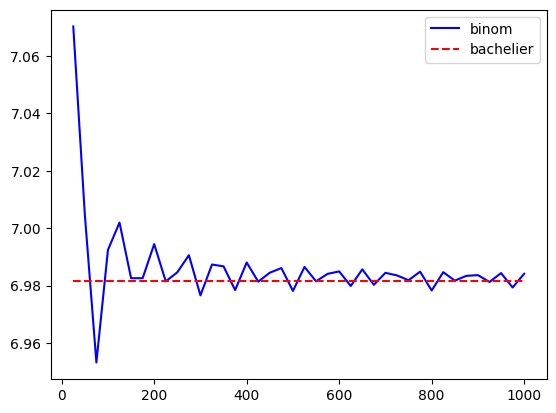

In [ ]:
# bachelier graph
ns = np.arange(25, 1025, 25)

S0 = 100
T = 2
K = 110

sigma = 20

tgt = bach_price(0, S0, sigma, K, T)

recon = generate_reconstruction_normal(S0)

prices = [binom_wrapper(T, n, sigma, recon, generate_european_call(n, K))[0][1][0] for n in ns]

plt.plot(ns, prices, 'b-', label = "binom")
plt.plot(ns, np.full(len(ns), tgt), 'r--', label="bachelier")
plt.legend()

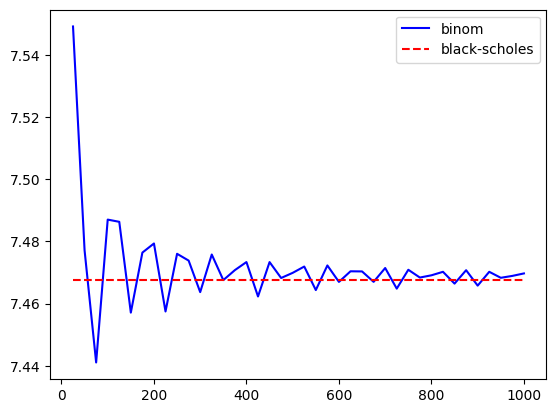

In [ ]:
# and Black and Scholes

sigma = .2

tgt = bs_price(0, S0, sigma, K, T)

recon = generate_reconstruction_lognormal(S0)

prices = [binom_wrapper(T, n, sigma, recon, generate_european_call(n, K))[0][1][0] for n in ns]

plt.plot(ns, prices, 'b-', label = "binom")
plt.plot(ns, np.full(len(ns), tgt), 'r--', label="black-scholes")
plt.legend()

# Question 5

You are now using the BOPM, not as a self-contained model, but as a *numerical method* for computing approximate solutions in a different, target model.

Numerical pricing methods are algorithms for computing approximate prices of some Derivative instruments, under the assumptions of a given model. Numerical methods are omnipresent in the Derivatives industry, where the vast majority of models and instruments are far too sophisticated to lend themselves to closed-form solutions. Besides, as you have seen, closed-form solutions are specific to given models and instruments, whereas well-designed numerical methods are generic and applicable to wide families of models and instruments, while written only once.

The BOPM was the first numerical method in finance, it is also the simplest, and the first one covered in class (although, technically, it is only covered in this homework). Methods generally admit size-like parameters, such as the number $n$ of time steps, such that the result should converge to the exact solution, in return for increased complexity, when size grows.

It is worth highlighting two important properties of the BOPM as a numerical method:

1. It is the model and not the solution that is approximated. The solution is the exact solution under an approximate model. This is not the case for all numerical methods, and a very desirable property. This means that, for a finite size, the computed prices may not exactly match the theoretical or market prices, but all prices are consistent and not mutually arbitrageable. For instance, if you price multiple calls in a BOPM of finite size $n$, you are guaranteed that prices a decreasing, convex functions of strike and increasing functions of maturity.

2. The BOPM does not only compute the price today, but also future prices on regularly spaced times $i T /n$, up to expiry, in different scenarios. Again, not all numerical methods can do this. Methods that have this property may be used, not only to compute the prices of European options, but also, to produce scenario-based risk-reward reports, or price options with early exercise, such as American options.

### American options

Most exchange-traded single-stock options in the US are American style. American options may be exercised not only at maturity, but at any time before maturity. The holder of the option can opt to exercise it at any time $t \in [0, t]$ and immediately enjoy the payoff $g(S_t)$. Of course, the option dies once exercised and cannot be exercised a second time. The holder may also opt to never exercise. An American call, for example, pays the *intrinsic value* $(S_{T_e} - K)^+$ on the exercise time $T_e$ chosen by the holder.

Prices of American options may be computed by *dynamic programming*. Denote $C_i$ the price at time $i$, *assuming no prior exercise*. Evidently, the price at time $0$ is just the price. To compute $C_i$, consider that the holder has a choice to exercice, or not. If she exercises, the option pays intrinsic value and dies. Otherwise, the option is kept alive, and its value, called *continuation value* and denoted $cont_i$, is simply the value of the American option with first exercise time $i+1$. The holder picks the decision that maximises value:

$$
  C_{ij} = \max({IV}_{ij}, cont_{ij})
$$

Of course:

$$
  cont_{ij} = E^Q_{ij}[C_{i+1}]
$$

and we have an induction on $(C_i)$:
$$
  C_{ij} = \max({IV}_{ij}, E^Q_{ij}[C_{i+1}])
$$

under the usual base case: $C_{nj} = {IV}_{nj}$.

The instrinsic value is some given payoff $g(S_t)$, for example, $(S_t-K)^+$ for the American call.

Therefore, American options are tractable with numerical methods that compute future prices, providing continuation values for the modeling of the exercise, but not with methods that only compute todays prices.

And finally comes the question: write a function that reuses your previous code to price an American call, and verify that the price exactly corresponds to its European counterpart. Why this is the case is treated in the next question.

Notice the power of generic pricing code: you are effectively reusing your template code to compute the price of a very different, much more sophisticated instrument. Your solution should be extremely quick and easy.

In [ ]:
def generate_american_call(n, K):
  # your code here
  pass

# testing

S0 = 100
recon = generate_reconstruction_lognormal(S0)

K = 120
T = 2
n = 200
sigma = .2

# uncomment where you are done
# am_price = binom_wrapper(T, n, sigma, recon, generate_american_call(n, K))[0][1][0]
# print(am_price)
# euro_price = binom_wrapper(T, n, sigma, recon, generate_european_call(n, K))[0][1][0]
# print(euro_price)
# assert(am_price == euro_price)

Solution:

In [ ]:
def generate_american_call(n, K):

  def update_func(s_i, i, c_i):
    if i == n:
      return np.where(s_i > K, s_i - K, 0)

    else:
      return np.maximum(c_i, s_i - K)

  return update_func

# testing

S0 = 100
recon = generate_reconstruction_lognormal(S0)

K = 120
T = 2
n = 200
sigma = .2

am_price = binom_wrapper(T, n, sigma, recon, generate_american_call(n, K))[0][1][0]
print(am_price)
euro_price = binom_wrapper(T, n, sigma, recon, generate_european_call(n, K))[0][1][0]
print(euro_price)
assert(am_price == euro_price)

4.841020610711791
4.841020610711791


# Question 6

### American call spreads

Use a model-free arbitrage argument to prove that one never early exercises an American call before expiry if there are no rates or dividends. Hence, American and European calls have the same value.

For this reason, you will now work with more interesting instruments: call spreads.

A call spread $K_1-K_2$ (with $K_2 > K_1$) is a simultaneous long position on the call strike $K_1$, and short position strike $K_2 > K_1$, with notional $1/(K_2 - K_1)$. The payoff is therefore:
$$
  g(S_T) = \frac{1}{K_2 - K_1} [(S_T - K_1)^+ - (S_T - K_2)^+]
$$

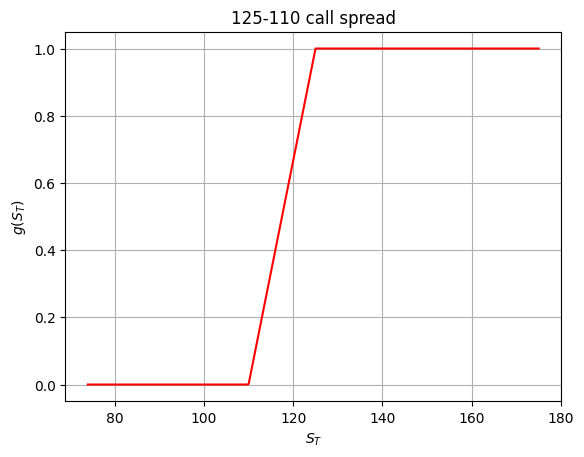

In [ ]:
def callspread_iv(spots, K1, K2):
  return (1 / (K2 - K1)) * (np.maximum(spots - K1, 0) - np.maximum(spots - K2, 0))

spots = np.linspace(74, 175, 500)
K1 = 110
K2 = 125

plt.plot(spots, callspread_iv(spots, K1, K2), "r-")
plt.title(f"{K2}-{K1} call spread")
plt.xlabel("$S_T$")
plt.ylabel("$g(S_T)$")
plt.grid()

American call spreads are American variants where the holder receives $g(S_t)$ at the time $t$ or her choosing, between inception and maturity.

1. Explain why you will want to early exercise the call spread whenever $S_t$ trades above $K_2$.

2. This may sound strange, since calls are never exercised early, and call spreads are combinations of calls. Resolve the "paradox".

3. Write the code for american call spreads. Notice, once, again, how easily you instrument your code, without modification, to deal with much more sophisticated instruments.

In [ ]:
def generate_callspread(n, K1, K2, american=True):
  # your code here
  pass

# testing
# set True when you are done
if False:

  S0 = 100
  recon = generate_reconstruction_lognormal(S0)

  T = 2
  n = 200
  sigma = .2

  am_price = binom_wrapper(T, n, sigma, recon, generate_callspread(n, K1, K2))[0][1][0]
  euro_price = binom_wrapper(T, n, sigma, recon, generate_callspread(n, K1, K2, american=False))[0][1][0]

  print(f"am_price: {am_price}")
  print(f"euro_price -- 1 bimom: {euro_price}")
  assert(am_price > euro_price)

  euro_price_check = binom_wrapper(T, n, sigma, recon, generate_european_call(n, K1))[0][1][0]
  euro_price_check -= binom_wrapper(T, n, sigma, recon, generate_european_call(n, K2))[0][1][0]
  euro_price_check /= K2 - K1
  print(f"euro_price -- binom calls: {euro_price_check}")

  euro_price_bs = (
      bs_price(0, S0, sigma, K1, T)
      - bs_price(0, S0, sigma, K2, T)
      ) / (K2 - K1)
  print(f"euro_price_bs: {euro_price_bs}")

Solution:

1. When $S_t \geq K_2$, the intrinsic value $K_2 - K_1$ is the best attainable payoff. It cannot get better and may well get worse from there. Exercising is therefore the dominating strategy.

2. An American call spread is *not* a spread of American calls, since it is the holder of the call-spread who exercises both options at once.

In [ ]:
def generate_callspread(n, K1, K2, american=True):

  def update_func(s_i, i, c_i):

    if i == n:
      return callspread_iv(s_i, K1, K2)

    else:
      if american:
        return np.maximum(c_i, callspread_iv(s_i, K1, K2))
      else:
        return c_i

  return update_func

# testing

S0 = 100
recon = generate_reconstruction_lognormal(S0)

T = 2
n = 200
sigma = .2

am_price = binom_wrapper(T, n, sigma, recon, generate_callspread(n, K1, K2))[0][1][0]
euro_price = binom_wrapper(T, n, sigma, recon, generate_callspread(n, K1, K2, american=False))[0][1][0]

print(f"am_price: {am_price}")
print(f"euro_price -- 1 bimom: {euro_price}")
assert(am_price > euro_price)

euro_price_check = binom_wrapper(T, n, sigma, recon, generate_european_call(n, K1))[0][1][0]
euro_price_check -= binom_wrapper(T, n, sigma, recon, generate_european_call(n, K2))[0][1][0]
euro_price_check /= K2 - K1
print(f"euro_price -- binom calls: {euro_price_check}")

euro_price_bs = (
    bs_price(0, S0, sigma, K1, T)
    - bs_price(0, S0, sigma, K2, T)
    ) / (K2 - K1)
print(f"euro_price_bs: {euro_price_bs}")

am_price: 0.39238006792547614
euro_price -- 1 bimom: 0.24116419027251307
euro_price -- binom calls: 0.24116419027251335
euro_price_bs: 0.24096099925777306


# Question 7

### Future profiles and exercise boundaries

You can leverage the capability of the bopm to compute future values to perform all kinds of risk and scenario analysis for diverse horizons. Here is an example:

Use Bachelier with spot $100$ and volatility $25$. Price an American and a European callspread 115-125 with maturity 2y. Use 200 steps.

Grab the midway (1y) results and plot:
* The European and American prices and IV as functions of the spot price that prevails in 1y time
* The exercise boundary

Solution:

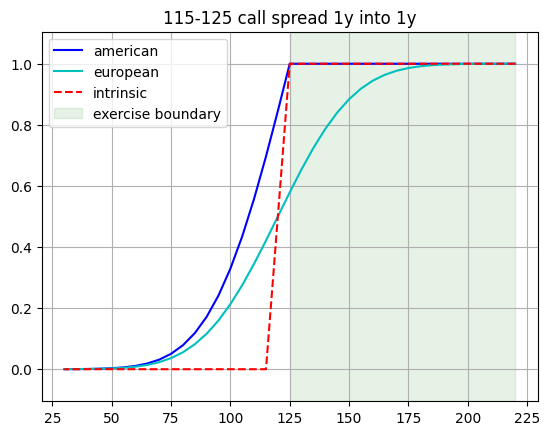

In [ ]:
S0 = 100
sigma = 25
recon = generate_reconstruction_normal(S0)

T = 2
n = 200

K1 = 115
K2 = 125

Lam = binom_wrapper(T, n, sigma, recon, generate_callspread(n, K1, K2))
Leu = binom_wrapper(T, n, sigma, recon, generate_callspread(n, K1, K2, american=False))

T0 = 1.0
spots, am_prices = Lam[T0]
temp, eu_prices = Leu[T0]
assert np.allclose(spots, temp)

# zoom into the more interesting region
indices = np.where((spots > 25) & (spots < 225))
spots = spots[indices]
am_prices = am_prices[indices]
eu_prices = eu_prices[indices]

ivs = callspread_iv(spots, K1, K2)
exercise = am_prices == ivs

plt.plot(spots, am_prices, 'b-', label="american")
plt.plot(spots, eu_prices, 'c-', label="european")
plt.plot(spots, ivs, 'r--', label="intrinsic")
plt.title(f"{K1}-{K2} call spread 1y into 1y")

plt.fill_between(spots, 0, 1, where=exercise, color='green', alpha=0.1, transform=plt.gca().get_xaxis_transform(), label="exercise boundary")

plt.legend()
plt.grid()


# Question 7

### Glimpse at numerical properties

Use Bachelier with spot $100$ and volatility $25$. Price a European callspread 115-125 with maturity 2y. Use 100 steps.

Grab the midway (1y) results and plot:
* The nodes of your binomial tree
* The risk-neutral density of $S_{1y}$
* A numerical estimate of gamma, using the 1y results

Repeat with 500 steps.
Comment and conclude.

Solution:

In [ ]:
def plot_nodes(n):

  S0 = 100
  sigma = 25
  recon = generate_reconstruction_normal(S0)

  T = 2

  K1 = 115
  K2 = 125

  L = binom_wrapper(T, n, sigma, recon, generate_callspread(n, K1, K2, american=False))

  T0 = 1.0
  spots, prices = L[T0]
  mesh = spots[0] - spots[1]
  assert np.allclose(-np.diff(spots), mesh)

  gaussian = norm.pdf(spots, loc = S0, scale = sigma * np.sqrt(T0))
  gammas = (prices[:-2] - 2 * prices[1:-1] + prices[2:]) / (mesh ** 2)

  plt.figure(figsize=(12, 4))

  plt.plot(spots, np.zeros_like(spots), 'b.', label="nodes")
  plt.plot(spots, gaussian, "c--", label="density")
  plt.ylim(-gaussian.max()*1.1, gaussian.max()*1.1)
  plt.legend(loc='upper left')
  plt.grid()

  plt.twinx().plot(spots[1:-1], gammas, "r--", label="gamma")
  plt.legend(loc='upper right')

  plt.title(f"{K1}-{K2} european call spread 1y into 1y")




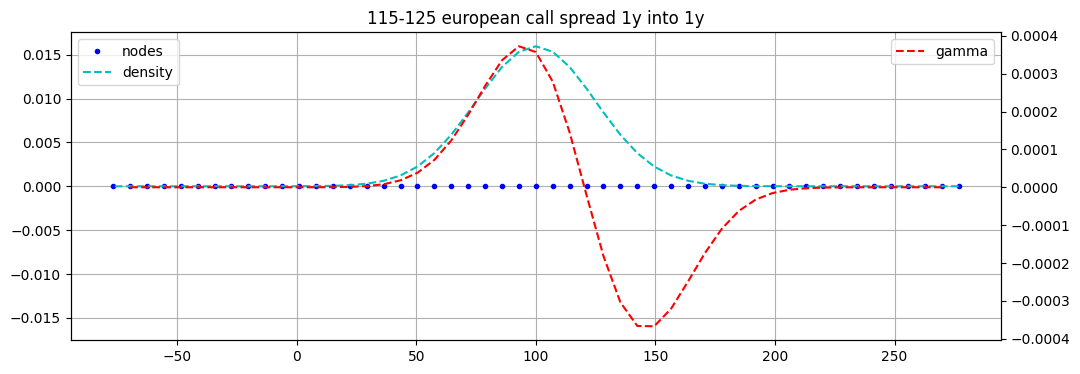

In [ ]:
plot_nodes(100)

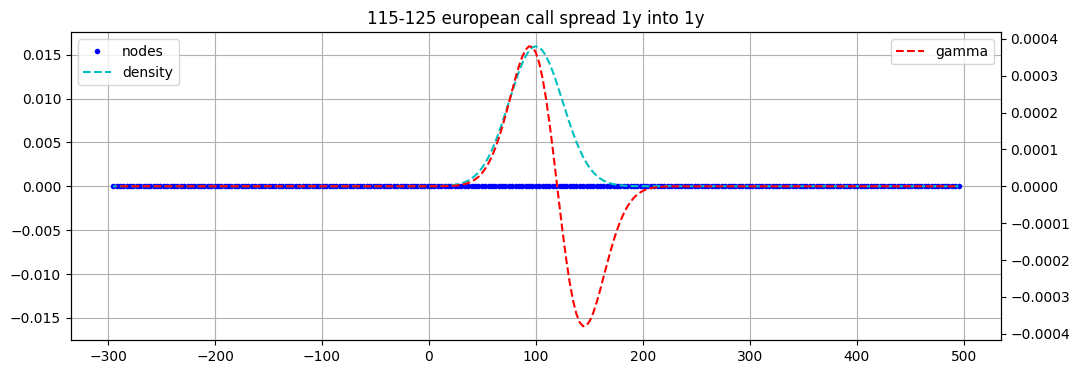

In [ ]:
plot_nodes(500)


It is apparent that the mesh is far too wide, and the range is ridiculously large, wasting considerable computing effort in regions with no probability or convexity, and its gets worse when the size increases.

This explains the underwhelming convergence order.

Of course, we would like to shrink the mesh and cooncentrate the nodes in the region that matters, around 0-200, but we can't do that with the binomial model: the mesh is not just a numerical parameter you can tweak, it is a fundamental model parameter, proportional to volatility.

Many simple or less simple things can be done to improve the numerical properties of the BOPM, but this is wasted effort, in our opinion, the far superior FDM method, sort-of "BOPM on steroids", is where you want to be in prusuit of numerical effectiveness.

# Final notes

The BOPM is not particularly powerful as a numerical method. It does not easily support more sophisticated models with state-dependent volatility, and its convergence is slow, with error vanishing in $O(1/n)$.

Its application today is limited to learning exercises and niche use cases in the industry. The much more powerful finite difference methods (FDM), which support state-dependent volatility, and have linear complexity with quadratic convergence order, have been industry state-of-the-art for several decades.

However, the BOPM remains a great environment for learning mathematical and computational finance, reasoning about nontrivial problems in a simplified context, and implementing pricing algorithms and design patterns without the interference of hard numerical problems.